In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/texas_monthly_dataset.csv', parse_dates=['date'])

print(df.head())
print(df.info())

   consumption       date  avg_temp_f  temp_departure
0        27584 2001-01-01        43.9            -3.1
1        24171 2001-02-01        51.9             1.1
2        22424 2001-03-01        53.3            -6.1
3        22635 2001-04-01        67.8             1.5
4        24516 2001-05-01        74.1             0.2
<class 'pandas.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   consumption     306 non-null    int64         
 1   date            306 non-null    datetime64[us]
 2   avg_temp_f      306 non-null    float64       
 3   temp_departure  306 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 9.7 KB
None


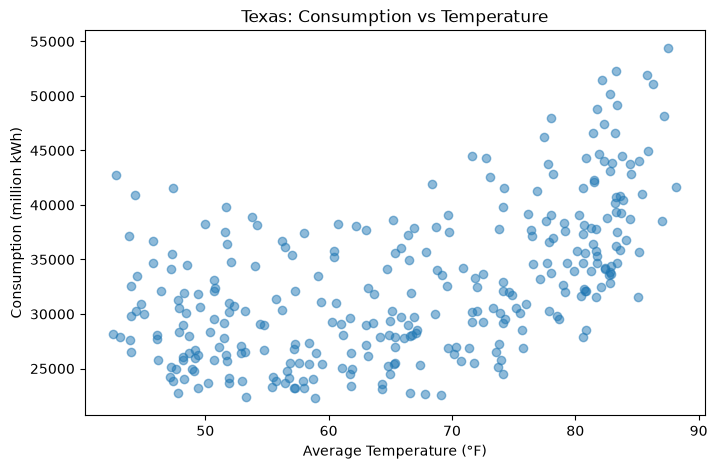

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['avg_temp_f'], df['consumption'], alpha=0.5)
plt.xlabel('Average Temperature (°F)')
plt.ylabel('Consumption (million kWh)')
plt.title('Texas: Consumption vs Temperature')
plt.show()

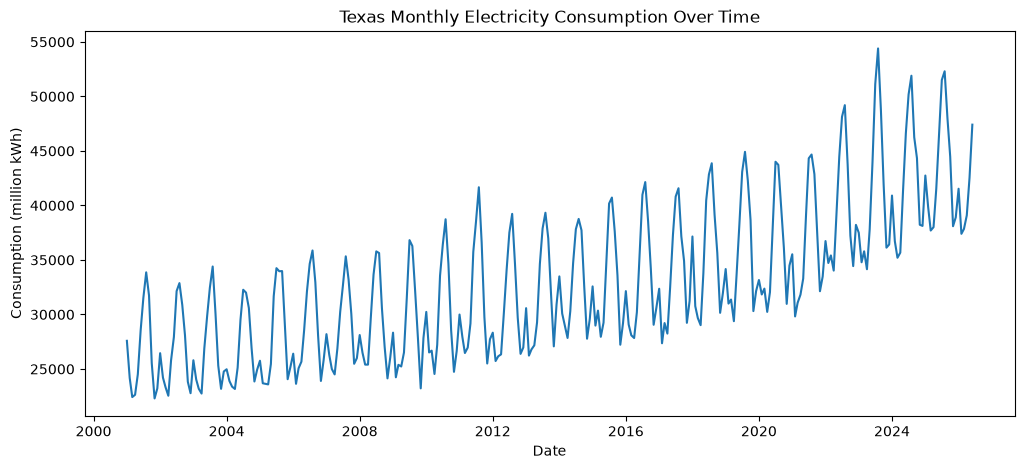

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['consumption'])
plt.xlabel('Date')
plt.ylabel('Consumption (million kWh)')
plt.title('Texas Monthly Electricity Consumption Over Time')
plt.show()


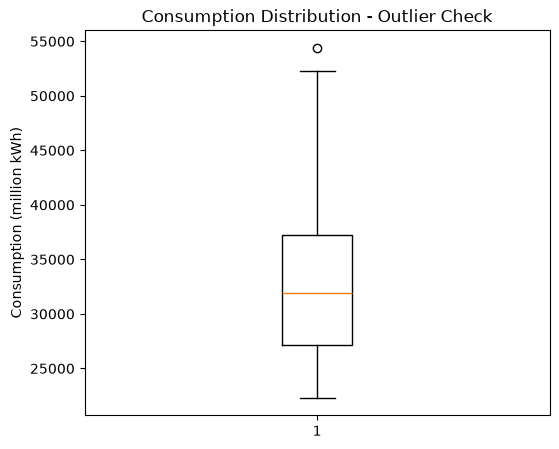

In [5]:
# رسمة Box Plot للتأكد من عدم وجود قيم شاذة (outliers) في الاستهلاك
plt.figure(figsize=(6, 5))  # تحديد حجم الرسمة

plt.boxplot(df['consumption'])  # رسم الصندوق: الوسيط + نطاق الـ 50% الأوسط + الشوارب + أي outliers كنقاط منفصلة

plt.ylabel('Consumption (million kWh)')  # تسمية المحور الرأسي
plt.title('Consumption Distribution - Outlier Check')  # عنوان الرسمة

plt.show()  # عرض الرسمة

In [6]:
# حساب معامل الارتباط بين كل الأعمدة الرقمية في الجدول
correlation_matrix = df[['consumption', 'avg_temp_f', 'temp_departure']].corr()

print(correlation_matrix)


                consumption  avg_temp_f  temp_departure
consumption        1.000000    0.543339        0.236278
avg_temp_f         0.543339    1.000000        0.193582
temp_departure     0.236278    0.193582        1.000000


In [7]:
# استخراج السنة والشهر كأعمدة منفصلة من عمود date
df['year'] = df['date'].dt.year    # .dt تسمح لنا نوصل لأجزاء التاريخ (سنة، شهر، يوم...)
df['month'] = df['date'].dt.month  # رقم الشهر (1 = يناير، 12 = ديسمبر)

# تحويل البيانات لجدول محوري: الشهور صفوف، السنين أعمدة، والقيم هي الاستهلاك
heatmap_data = df.pivot_table(index='month', columns='year', values='consumption')

print(heatmap_data.head())

year      2001     2002     2003     2004     2005     2006     2007     2008  \
month                                                                           
1      27584.0  26449.0  25800.0  24973.0  25756.0  26402.0  28194.0  28113.0   
2      24171.0  24207.0  24035.0  23894.0  23689.0  23641.0  26280.0  26480.0   
3      22424.0  23338.0  23188.0  23379.0  23644.0  25065.0  24998.0  25401.0   
4      22635.0  22545.0  22746.0  23167.0  23587.0  25670.0  24502.0  25400.0   
5      24516.0  25791.0  26881.0  25132.0  25462.0  28564.0  26883.0  29581.0   

year      2009     2010  ...     2017     2018     2019     2020     2021  \
month                    ...                                                
1      28332.0  30235.0  ...  32359.0  37151.0  34165.0  33161.0  35518.0   
2      24238.0  26518.0  ...  27358.0  30762.0  30997.0  31834.0  29819.0   
3      25380.0  26681.0  ...  29212.0  29675.0  31368.0  32371.0  31074.0   
4      25230.0  24542.0  ...  28247.0  29019.0 

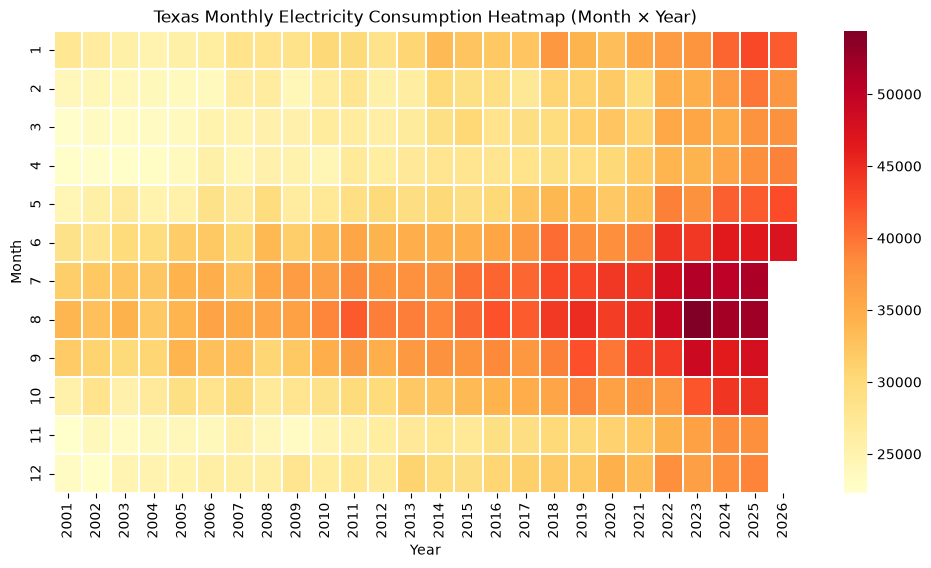

In [8]:
import seaborn as sns

# تصغير حجم الرسمة الكلي عشان الخانات متبقاش كبيرة أوي (25 سنة × 12 شهر)
plt.figure(figsize=(12, 6))

# رسم الهيت ماب:
sns.heatmap(
    heatmap_data,       # الجدول المحوري اللي جهزناه
    cmap='YlOrRd',       # تدرج لوني من الأصفر للأحمر (زي المثال اللي بعتيه)
    annot=False,          # مش هنكتب الرقم جوه كل خانة (عشان الخانات صغيرة، الأرقام هتتلخبط)
    linewidths=0.3        # خط رفيع بين الخانات يفصلها بصرياً
)

plt.title('Texas Monthly Electricity Consumption Heatmap (Month × Year)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()